# Model Comparison

## Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (StratifiedKFold,RandomizedSearchCV,cross_validate)
from sklearn.metrics import (precision_score,recall_score,roc_auc_score,accuracy_score,f1_score,roc_curve)
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings("ignore")

## 1. Modeling preparation

In [2]:
DATA_DIR = Path("../Cleaned Data/Splits")      # Training and test set folder
RESULT_DIR = Path("../Result")                 # Save Results
RESULT_DIR.mkdir(parents=True, exist_ok=True)  # Create the result folder if it does not exist
RANDOM_STATE = 1948883                         # Using My ID as a random seed, make the results reproducible.
N_SPLITS = 5                                   # 5-fold cross-validation
N_ITER_TREE = 40                               # RandomizedSearchCV tries 40 random hyperparameter combinations for the decision tree.
N_ITER_RF = 40                                 # RandomizedSearchCV tries 40 random hyperparameter combinations for the random forest.
N_ITER_XGB = 40                                # RandomizedSearchCV tries 40 random hyperparameter combinations for XGBoost.


# 4 modeling tasks.
TASKS = {
    "before_mask": "Before mandate - Face mask",                    # 1. Predict face mask behavior before the mask mandate.
    "after_mask": "After mandate - Face mask",                      # 2. Predict face mask behavior after the mask mandate.
    "before_protective": "Before mandate - Protective behaviour",   # 3. Predict protective behavior before the mask mandate.
    "after_protective": "After mandate - Protective behaviour",     # 4. Predict protective behavior after the mask mandate.
}
TASK_ORDER = list(TASKS.keys())
MODEL_ORDER = ["logistic_regression","classification_tree","random_forest","xgboost" ]   # Define the model display order.
MODEL_LABELS = {"logistic_regression": "Logistic regression","classification_tree": "Classification tree","random_forest": "Random forest","xgboost": "XGBoost" }  # Convert internal model names into readable labels.


# Evaluation indicators     
METRIC_ORDER = ["roc_auc", "precision", "recall", "accuracy", "f1"]    # The metrics
SCORING = {"roc_auc": "roc_auc", "precision": "precision", "recall": "recall", "accuracy": "accuracy", "f1": "f1" }   # Define the evaluation metrics used in cross-validation and model comparison.

## 2. Helper functions

In [3]:
# Load the training and test data
def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")                           # Training data
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")                             # Test data
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)    # Convert training data to integer labels
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)      # Convert Test data to integer labels
    return X_train, X_test, y_train, y_test


# Calculate the classification performance metrics
def get_metrics(y_true, y_pred, y_prob):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),                             # ROC_AUC 
        "precision": precision_score(y_true, y_pred, zero_division=0),        # Preccision
        "recall": recall_score(y_true, y_pred, zero_division=0),              # Recall
        "accuracy": accuracy_score(y_true, y_pred),                           # Accuracy
        "f1": f1_score(y_true, y_pred, zero_division=0)                       # F1 Score
    }


# Calculate the mean and standard error of cross-validation scores
def mean_se(values):
    values = np.asarray(values, dtype=float)
    return values.mean(), values.std(ddof=1) / np.sqrt(len(values))



# Format the mean and standard error
def format_mean_se(mean_val, se_val):
    return f"{mean_val:.3f} ({se_val:.3f})"


# Extract feature importance
def extract_feature_importance(fitted_pipeline, feature_names, model_name):
    model = fitted_pipeline.named_steps["model"]

    if model_name == "logistic_regression":             # For logistic regression, use the absolute coefficient values as importance scores
        values = np.abs(model.coef_.ravel())            
    elif hasattr(model, "feature_importances_"):        # For tree-based models, use the built in feature_importances_ as importance scores
        values = model.feature_importances_
    else:
        values = np.zeros(len(feature_names))           # If the model does not provide feature importance, its 0

    return (pd.DataFrame({"feature": feature_names,"importance": values}).sort_values("importance", ascending=False).reset_index(drop=True))


# Assign each feature to a broader conceptual category.
def feature_category(feature):
    f = feature.lower()

    # Some self-protective behaviors
    if any(k in f for k in ["mask", "protective", "wash", "sanit", "distance", "contacts","isolate", "quarantine", "non_household", "household_contacts"]):
        return "Self-protective behaviours"
    # Demographics
    if any(k in f for k in ["age", "gender", "sex", "male", "female", "employment", "household","state", "region", "territory", "student", "retired", "unemployed"]):
        return "Demographics"
    # Trust in the government
    if any(k in f for k in ["confidence", "government", "trust"]):
        return "Trust in government"
    # Some psychological factors
    if any(k in f for k in ["wellbeing", "ladder", "phq", "anx", "depress", "worry", "nervous","comorbid", "health", "mental"]):
        return "Health, mental health and wellbeing"
    # Self-awareness
    if any(k in f for k in ["severity", "susceptibility", "threat", "dangerous", "likely_get", "risk"]):
        return "Perception of illness threat"
    # Time
    if any(k in f for k in ["week", "date", "time", "period"]):
        return "Time"

    return "Other"


# The display order of feature categories
CATEGORY_ORDER = ["Self-protective behaviours","Demographics","Health, mental health and wellbeing","Perception of illness threat","Time","Trust in government","Other"]

# Colour for visualising feature categories
CATEGORY_COLORS = {"Self-protective behaviours": "#12577c","Demographics": "#74adca","Health, mental health and wellbeing": "#6baed6","Perception of illness threat": "#bdb39f","Time": "#e09135","Trust in government": "#b45f06","Other": "#404040"}

## 3. Model definitions

In [4]:
# Logistic Regression pipeline
def build_logistic_pipeline():
    return Pipeline(steps=[("ros", RandomOverSampler(random_state=RANDOM_STATE)),                                        # Random oversampling
                           ("model", LogisticRegression(max_iter=5000,solver="liblinear",random_state=RANDOM_STATE))])   # iterations, Solver, Random state


# Decision Tree pipeline
def build_tree_search():
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),                         # Random oversampling
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))])                 # Random state
    
    param_distributions = {                                                            # The hyperparameter search space
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30, 50],
        "model__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.005, 0.01],}

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)   # Stratified 5-fold cross-validation

    return RandomizedSearchCV(estimator=pipe,param_distributions=param_distributions,n_iter=N_ITER_TREE,scoring="roc_auc",cv=cv,random_state=RANDOM_STATE,n_jobs=1,refit=True,verbose=0,)


# Random Forest pipeline
def build_rf_search():
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),                                      # Random oversampling
        ("model", RandomForestClassifier(n_estimators=250,random_state=RANDOM_STATE,n_jobs=-1))])   # Number of trees, Random state, CPU

    param_distributions = {                                                                         # The hyperparameter search space
        "model__max_depth": [5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "model__bootstrap": [True],}

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)                # Stratified 5-fold cross-validation

    return RandomizedSearchCV(estimator=pipe,param_distributions=param_distributions,n_iter=N_ITER_RF,scoring="roc_auc",cv=cv,random_state=RANDOM_STATE,n_jobs=1,refit=True,verbose=0,)


# XGBoost pipeline
def build_xgb_search():
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),                                                                                                  # Random oversampling
        ("model", XGBClassifier(n_estimators=250,objective="binary:logistic",eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist"))])   # Number of boosting trees, Binary classification objective, Evaluation metric

    param_distributions = {                                                                                                                                     # The hyperparameter search space
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0, 0.01, 0.1, 0.3, 0.5, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)                                                                            # Stratified 5-fold cross-validation

    return RandomizedSearchCV(estimator=pipe,param_distributions=param_distributions,n_iter=N_ITER_XGB,scoring="roc_auc",cv=cv,random_state=RANDOM_STATE,n_jobs=1,refit=True,verbose=0)


## 4. Model training functions

In [5]:
# Train and evaluate the logistic regression model
def run_logistic(X_train, X_test, y_train, y_test):
    pipe = build_logistic_pipeline()
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)                        # Define stratified cross-validation

    cv_res = cross_validate(pipe,X_train,y_train,scoring=SCORING,cv=cv,return_train_score=False,n_jobs=1)   # Evaluate Logistic Regression using cross-validation on the training data.

    pipe.fit(X_train, y_train)                                          # Fit the Logistic Regression model

    y_test_pred = pipe.predict(X_test)                                  # Generate class predictions
    y_test_prob = pipe.predict_proba(X_test)[:, 1]                      # Generate predicted probabilities

    # Summarise the cross-validation results as mean and standard error.
    cv_summary = {}
    for metric in METRIC_ORDER:
        mean_val, se_val = mean_se(cv_res[f"test_{metric}"])
        cv_summary[metric] = {"mean": mean_val,"se": se_val,"formatted": format_mean_se(mean_val, se_val)}

    return {"best_estimator": pipe,"best_params": {},"cv_summary": cv_summary,"test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),"y_test": y_test,"y_test_prob": y_test_prob,"feature_df": extract_feature_importance(pipe, X_train.columns, "logistic_regression"),}



# Find the best model
def run_search_model(search, X_train, X_test, y_train, y_test, model_name):
    search.fit(X_train, y_train)                                                                                   # Run randomized hyperparameter search on the training data
    best_pipe = search.best_estimator_                                                                             # Extract the best pipeline found by the search

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)                               # Evaluate the selected best model using stratified cross-validation
    cv_res = cross_validate(best_pipe,X_train,y_train,scoring=SCORING,cv=cv,return_train_score=False,n_jobs=1)

    best_pipe.fit(X_train, y_train)                                            # Fit the selected best model on the training set                         

    y_test_pred = best_pipe.predict(X_test)                                    # Generate class predictions and predicted probabilities on the test set
    y_test_prob = best_pipe.predict_proba(X_test)[:, 1]                       

    cv_summary = {}                                                            # Summarise the cross-validation results as mean and standard error
    for metric in METRIC_ORDER:
        mean_val, se_val = mean_se(cv_res[f"test_{metric}"])
        cv_summary[metric] = {"mean": mean_val,"se": se_val,"formatted": format_mean_se(mean_val, se_val)}

    return {"best_estimator": best_pipe,"best_params": search.best_params_,"cv_summary": cv_summary,"test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),"y_test": y_test,"y_test_prob": y_test_prob,"feature_df": extract_feature_importance(best_pipe, X_train.columns, model_name),}



# Map each model name to its corresponding training and evaluation function.
runner_map = {
    "logistic_regression": lambda X_train, X_test, y_train, y_test: run_logistic(X_train, X_test, y_train, y_test),
    "classification_tree": lambda X_train, X_test, y_train, y_test: run_search_model(build_tree_search(), X_train, X_test, y_train, y_test, "classification_tree"),
    "random_forest": lambda X_train, X_test, y_train, y_test: run_search_model(build_rf_search(), X_train, X_test, y_train, y_test, "random_forest"),
    "xgboost": lambda X_train, X_test, y_train, y_test: run_search_model(build_xgb_search(), X_train, X_test, y_train, y_test, "xgboost")}


## 5. Run all models

In [6]:
all_results = {}                                            # Create an empty dictionary to store all results from all tasks

for task in TASK_ORDER:                                     # Loop through each modeling task
    print(f"Running task: {TASKS[task]}")

    X_train, X_test, y_train, y_test = load_task(task)      # Load
    task_results = {}                                       # Create a dictionary to store results for all models in this task.

    for model_name in MODEL_ORDER:
        task_results[model_name] = runner_map[model_name](X_train, X_test, y_train, y_test)                         # Train and evaluate
    all_results[task] = {"label": TASKS[task],"feature_names": list(X_train.columns),"models": task_results}        # Store the task label, feature names, and model results.

print("\nAll tasks completed.")                             # Print


Running task: Before mandate - Face mask
Running task: After mandate - Face mask
Running task: Before mandate - Protective behaviour
Running task: After mandate - Protective behaviour

All tasks completed.


## 6.   Comparison tables

In [7]:
# Create a table to summarise cross-validation results for every task and model.
cv_rows = []
for task in TASK_ORDER:
    for model_name in MODEL_ORDER:                                                   # Get the stored results for the current task and model
        res = all_results[task]["models"][model_name]
        row = {"task": task,"Task": TASKS[task],"Model": MODEL_LABELS[model_name]}   # Store task information and model name

        for metric in METRIC_ORDER:                                                  # Add formatted CV metrics and their numeric mean values
            row[metric] = res["cv_summary"][metric]["formatted"]
            row[f"{metric}_mean"] = res["cv_summary"][metric]["mean"]
        cv_rows.append(row)

cv_table_full = pd.DataFrame(cv_rows)                                                # Convert the CV results into a DataFrame


selected_rows = []                                                                   # Select best model


# Find the model with the highest mean cross-validation ROC AUC
for task in TASK_ORDER:
    best_model_name = max(
        MODEL_ORDER,
        key=lambda m: all_results[task]["models"][m]["cv_summary"]["roc_auc"]["mean"])
    
    best_res = all_results[task]["models"][best_model_name]                          # Get the results of the selected best model.

    selected_rows.append({                                                           # Store the selected model and its test-set performance.
        "task": task,
        "Task": TASKS[task],
        "Selected model": MODEL_LABELS[best_model_name],
        "selected_model_key": best_model_name,
        "CV AUC": best_res["cv_summary"]["roc_auc"]["mean"],
        "AUC": best_res["test_metrics"]["roc_auc"],
        "Precision": best_res["test_metrics"]["precision"],
        "Recall": best_res["test_metrics"]["recall"],
        "Accuracy": best_res["test_metrics"]["accuracy"],
        "F1": best_res["test_metrics"]["f1"]})

selected_model_df = pd.DataFrame(selected_rows)                                      # Convert selected model results into a DataFrame



test_rows = []                                                                       # Create a test performance table for the selected best model of each task

for _, row in selected_model_df.iterrows():
    task = row["task"]                                                               # Get the task and selected model key
    model_name = row["selected_model_key"]
    res = all_results[task]["models"][model_name]                                    # Retrieve the selected model results

    test_rows.append({                                                               # Store rounded test-set metrics for reporting.
        "Task": TASKS[task],
        "Selected model": MODEL_LABELS[model_name],
        "AUC": round(res["test_metrics"]["roc_auc"], 3),
        "Precision": round(res["test_metrics"]["precision"], 3),
        "Recall": round(res["test_metrics"]["recall"], 3),
        "Accuracy": round(res["test_metrics"]["accuracy"], 3),
        "F1": round(res["test_metrics"]["f1"], 3)})

test_table_selected = pd.DataFrame(test_rows)                                        # Convert selected test results into a DataFrame


test_metric_rows = []                                                                # Create a long format table of test metrics for all tasks and models.

for task in TASK_ORDER:
    for model_name in MODEL_ORDER:
        res = all_results[task]["models"][model_name]
        test_metric_rows.append({"task": task,"Task": TASKS[task],"model": model_name,"Model": MODEL_LABELS[model_name],**res["test_metrics"]})

test_metrics_long = pd.DataFrame(test_metric_rows)                                   # Convert all test metrics into a long format DataFrame


# Create wide format tables for comparing AUC and F1 across tasks and models
auc_pivot = test_metrics_long.pivot(index="Model", columns="Task", values="roc_auc").round(3)
f1_pivot = test_metrics_long.pivot(index="Model", columns="Task", values="f1").round(3)


## 7. Summary tables

In [8]:
display(Markdown("## Table 1. Fivefold cross-validation results"))                          # The title

# Selct the columns
cv_display = cv_table_full[["Task", "Model", "roc_auc", "precision", "recall", "accuracy", "f1"]].rename(columns={"roc_auc": "AUC","precision": "Precision","recall": "Recall","accuracy": "Accuracy","f1": "F1"})
display(cv_display)                                                                         # Cross-validation results table                                                                        


cv_display.to_csv(RESULT_DIR / "table_cv_results.csv", index=False)
cv_table_full.to_csv(RESULT_DIR / "table_cv_results_full.csv", index=False)                 # The full cross-validation table（ including  mean values ）
display(Markdown("## Table 2. Held-out test results for the selected models"))
display(test_table_selected)


test_table_selected.to_csv(RESULT_DIR / "table_test_results.csv", index=False)              # Save the selected models' held-out test results
selected_model_df.to_csv(RESULT_DIR / "selected_model_summary.csv", index=False)
display(Markdown("## Selected model by task (selected using CV AUC)"))
display(selected_model_df.drop(columns=["selected_model_key"]))


display(Markdown("## AUC pivot (test set)"))                                                # AUC
display(auc_pivot)


display(Markdown("## F1 pivot (test set)"))                                                 # F1
display(f1_pivot)


auc_pivot.to_csv(RESULT_DIR / "auc_pivot.csv")                                              # Save the AUC pivot table
f1_pivot.to_csv(RESULT_DIR / "f1_pivot.csv")                                                # Save the F1 pivot table


## Table 1. Fivefold cross-validation results

,Task,Model,AUC,Precision,Recall,Accuracy,F1
0,Before mandate - Face mask,Logistic regression,0.821 (0.006),0.510 (0.007),0.774 (0.010),0.729 (0.006),0.615 (0.007)
1,Before mandate - Face mask,Classification tree,0.819 (0.007),0.516 (0.005),0.736 (0.008),0.734 (0.004),0.607 (0.006)
2,Before mandate - Face mask,Random forest,0.857 (0.005),0.616 (0.009),0.701 (0.014),0.794 (0.005),0.655 (0.009)
3,Before mandate - Face mask,XGBoost,0.864 (0.004),0.639 (0.013),0.676 (0.010),0.802 (0.006),0.656 (0.008)
4,After mandate - Face mask,Logistic regression,0.836 (0.004),0.879 (0.004),0.780 (0.004),0.769 (0.003),0.826 (0.003)
5,After mandate - Face mask,Classification tree,0.859 (0.003),0.883 (0.001),0.863 (0.006),0.823 (0.005),0.873 (0.004)
6,After mandate - Face mask,Random forest,0.890 (0.003),0.890 (0.003),0.893 (0.003),0.847 (0.004),0.892 (0.003)
7,After mandate - Face mask,XGBoost,0.893 (0.004),0.892 (0.003),0.905 (0.003),0.856 (0.004),0.899 (0.003)
8,Before mandate - Protective behaviour,Logistic regression,0.733 (0.002),0.658 (0.004),0.699 (0.006),0.673 (0.004),0.678 (0.004)
9,Before mandate - Protective behaviour,Classification tree,0.740 (0.006),0.667 (0.007),0.706 (0.018),0.682 (0.008),0.686 (0.010)


## Table 2. Held-out test results for the selected models

,Task,Selected model,AUC,Precision,Recall,Accuracy,F1
0,Before mandate - Face mask,XGBoost,0.866,0.622,0.675,0.794,0.647
1,After mandate - Face mask,XGBoost,0.898,0.890,0.895,0.848,0.892
2,Before mandate - Protective behaviour,XGBoost,0.783,0.690,0.703,0.698,0.696
3,After mandate - Protective behaviour,XGBoost,0.848,0.856,0.811,0.773,0.833


## Selected model by task (selected using CV AUC)

,task,Task,Selected model,CV AUC,AUC,Precision,Recall,Accuracy,F1
0,before_mask,Before mandate - Face mask,XGBoost,0.863824,0.865559,0.621988,0.674837,0.794333,0.647335
1,after_mask,After mandate - Face mask,XGBoost,0.892985,0.898367,0.890040,0.894676,0.847910,0.892352
2,before_protective,Before mandate - Protective behaviour,XGBoost,0.787788,0.782581,0.689718,0.703154,0.697898,0.696371
3,after_protective,After mandate - Protective behaviour,XGBoost,0.844211,0.847625,0.855511,0.810708,0.772681,0.832507


## AUC pivot (test set)

Task,After mandate - Face mask,After mandate - Protective behaviour,Before mandate - Face mask,Before mandate - Protective behaviour
Model,,,,
Classification tree,0.869,0.793,0.830,0.734
Logistic regression,0.844,0.769,0.828,0.722
Random forest,0.895,0.836,0.861,0.780
XGBoost,0.898,0.848,0.866,0.783


## F1 pivot (test set)

Task,After mandate - Face mask,After mandate - Protective behaviour,Before mandate - Face mask,Before mandate - Protective behaviour
Model,,,,
Classification tree,0.877,0.794,0.630,0.676
Logistic regression,0.831,0.778,0.616,0.666
Random forest,0.893,0.830,0.645,0.702
XGBoost,0.892,0.833,0.647,0.696


## 8. Tables and Figures

### 8.1 Helper function for grouped table figures


In [9]:
# Resize
def compute_col_widths(df, columns, min_frac=0.10, max_frac=0.30, padding=2):
    lens = []                                                                   
    for col in columns:
        max_len = len(str(col))
        for v in df[col].astype(str):
            max_len = max(max_len, len(v))
        lens.append(max_len + padding)
    total = sum(lens)
    widths = [x / total for x in lens]
    widths = [max(min_frac, min(max_frac, w)) for w in widths]                  
    s = sum(widths)
    widths = [w / s for w in widths]
    return widths


# Group
def draw_grouped_table(df,title,out_path,group_col,display_cols,figsize=(14, 8),font_size=10,header_font_size=11,title_font_size=14,group_fill="#d9d9d9",header_fill="black",edge_color="#666666",line_width=0.8,col_widths=None,left_pad_frac=0.015,row_height_data=1.0,row_height_group=1.0,dpi=300):
    df = df.copy()                                                  # Make Copy
    if col_widths is None:
        col_widths = compute_col_widths(df, display_cols)

    row_spec = [("header", None)]                                   # Row
    for g, sub in df.groupby(group_col, sort=False):
        row_spec.append(("group", g))
        for _, row in sub.iterrows():
            row_spec.append(("data", row))

    heights = []                                                    # Height
    for kind, _ in row_spec:
        if kind == "header":
            heights.append(1.0)
        elif kind == "group":
            heights.append(row_height_group)
        else:
            heights.append(row_height_data)
    total_h = sum(heights)                                          # Total height

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, total_h + 0.9)   
    ax.axis("off")
    ax.text(0.5, total_h + 0.55, title,ha="center", va="bottom",fontsize=title_font_size)
    x_positions = [0]
    for w in col_widths[:-1]:
        x_positions.append(x_positions[-1] + w)
    y = total_h

    for (kind, payload), h in zip(row_spec, heights):               # Draw
        y -= h
        if kind == "header":
            for col, x, w in zip(display_cols, x_positions, col_widths):
                ax.add_patch(Rectangle((x, y), w, h,facecolor=header_fill,edgecolor="black",linewidth=line_width))
                ax.text(x + w / 2, y + h / 2, str(col),ha="center", va="center",color="white",fontsize=header_font_size,fontweight="bold")
        elif kind == "group":
            ax.add_patch(Rectangle((0, y), 1, h,facecolor=group_fill,edgecolor=edge_color,linewidth=line_width))
            ax.text(left_pad_frac, y + h / 2, str(payload),ha="left", va="center",fontsize=font_size,fontweight="bold")
        else:
            row = payload
            for i, (col, x, w) in enumerate(zip(display_cols, x_positions, col_widths)):
                ax.add_patch(Rectangle((x, y), w, h,facecolor="white",edgecolor=edge_color,linewidth=line_width))
                txt = str(row[col])
                if i == 0:
                    ax.text(x + left_pad_frac, y + h / 2, txt,ha="left", va="center",fontsize=font_size)
                else:
                    ax.text(x + w / 2, y + h / 2, txt,ha="center", va="center",fontsize=font_size)


    # Visualization
    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()

### 8.2 Table 1

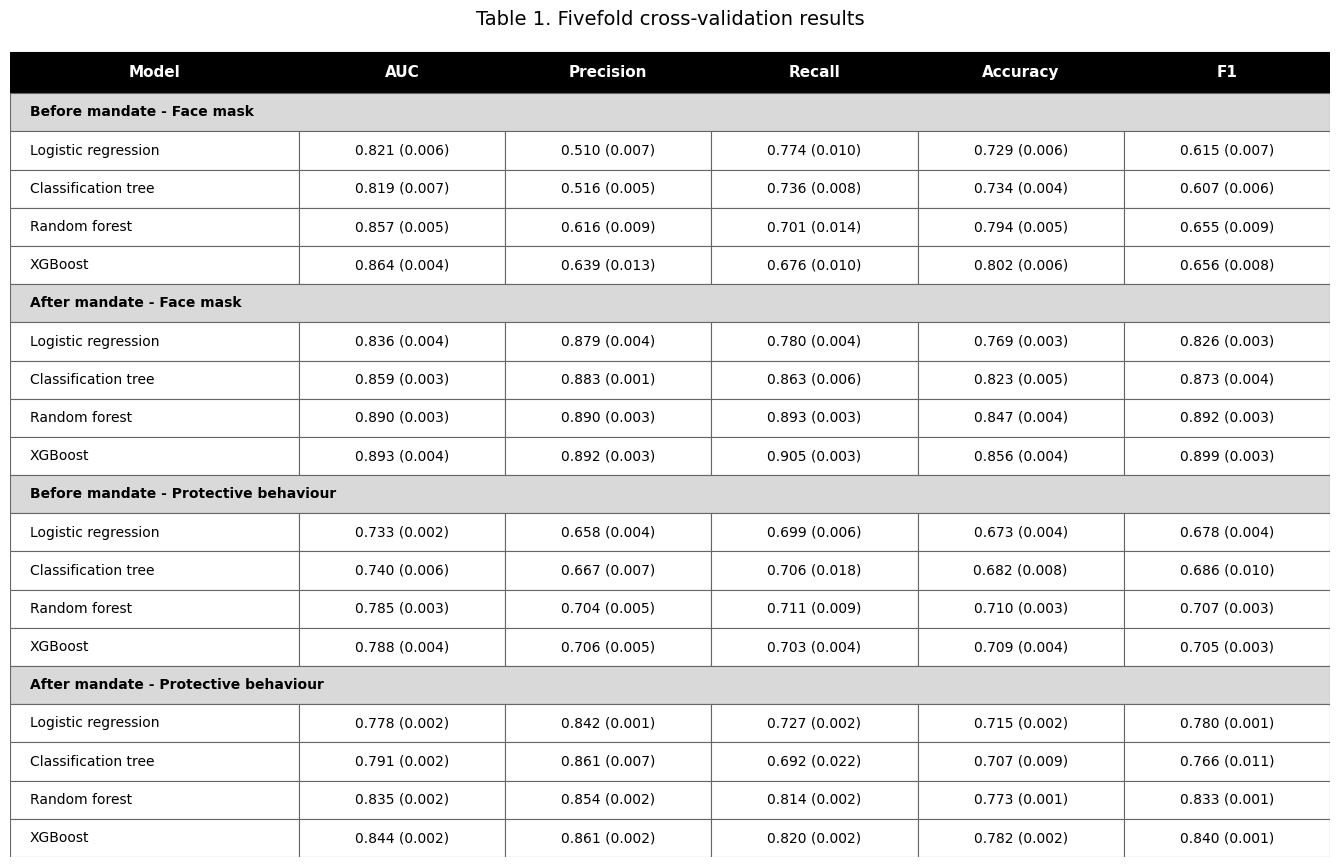

In [10]:
# All models' corss-validation results
draw_grouped_table(df=cv_display,
    title="Table 1. Fivefold cross-validation results",out_path=RESULT_DIR / "table_cv_results.png",group_col="Task",
    display_cols=["Model", "AUC", "Precision", "Recall", "Accuracy", "F1"],figsize=(13.5, 8.8),font_size=10,
    header_font_size=11,title_font_size=14,row_height_data=0.92,row_height_group=0.92)

### 8.3 Table 2

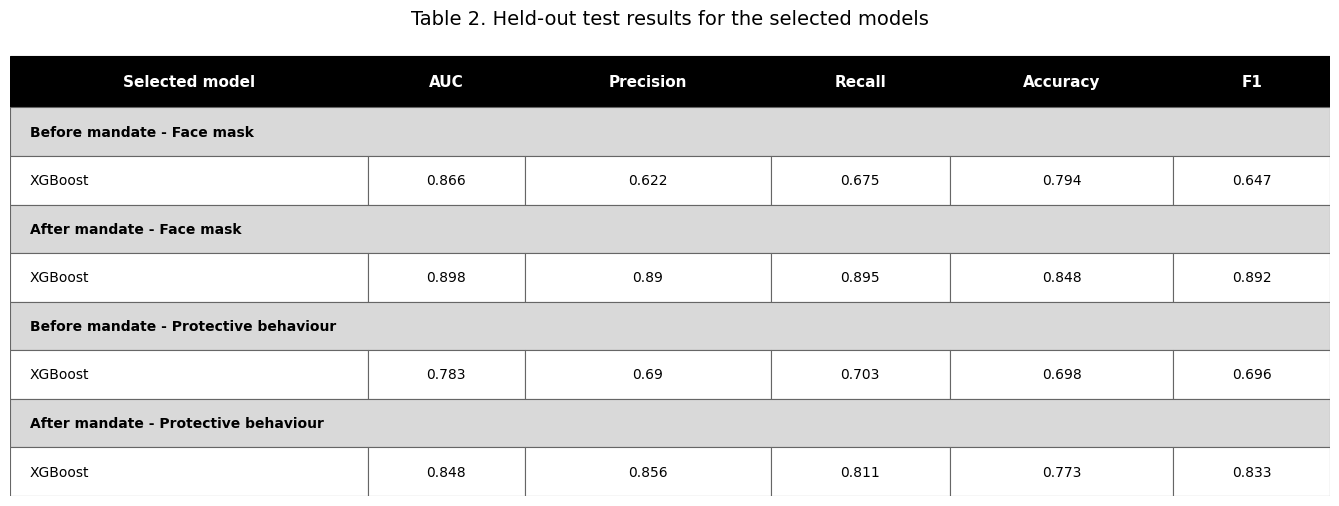

In [11]:
# Best models' results(XGboost)
draw_grouped_table(
    df=test_table_selected,title="Table 2. Held-out test results for the selected models",out_path=RESULT_DIR / "table_test_results.png",group_col="Task",
    display_cols=["Selected model", "AUC", "Precision", "Recall", "Accuracy", "F1"],figsize=(13.5, 5.2),font_size=10,header_font_size=11,
    title_font_size=14,row_height_data=0.95,row_height_group=0.95)

## 9. ROC curves

### 9.1 XGboost ROC curves

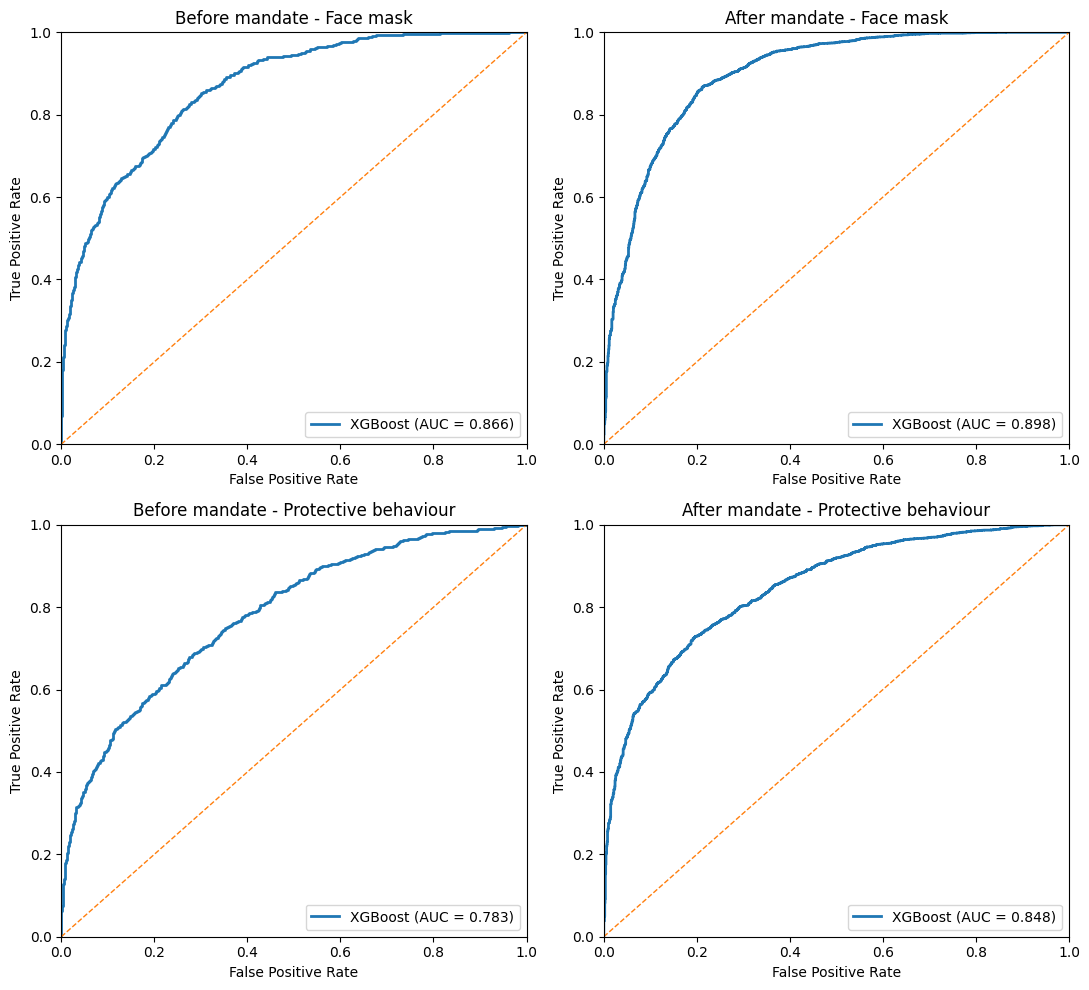

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))            # Create coordinates
axes = axes.flatten()

for ax, task in zip(axes, TASK_ORDER):
    selected_model_name = selected_model_df.loc[selected_model_df["task"] == task, "selected_model_key"].iloc[0]        # The best model
    selected_res = all_results[task]["models"][selected_model_name]

    y_true = selected_res["y_test"]
    y_prob = selected_res["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    ax.plot(fpr, tpr, linewidth=2, label=f"{MODEL_LABELS[selected_model_name]} (AUC = {auc_val:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Visulization
plt.tight_layout()
plt.savefig(RESULT_DIR / "roc_selected_models.png", bbox_inches="tight", dpi=300)
plt.show()

### 9.2 All ROC curves

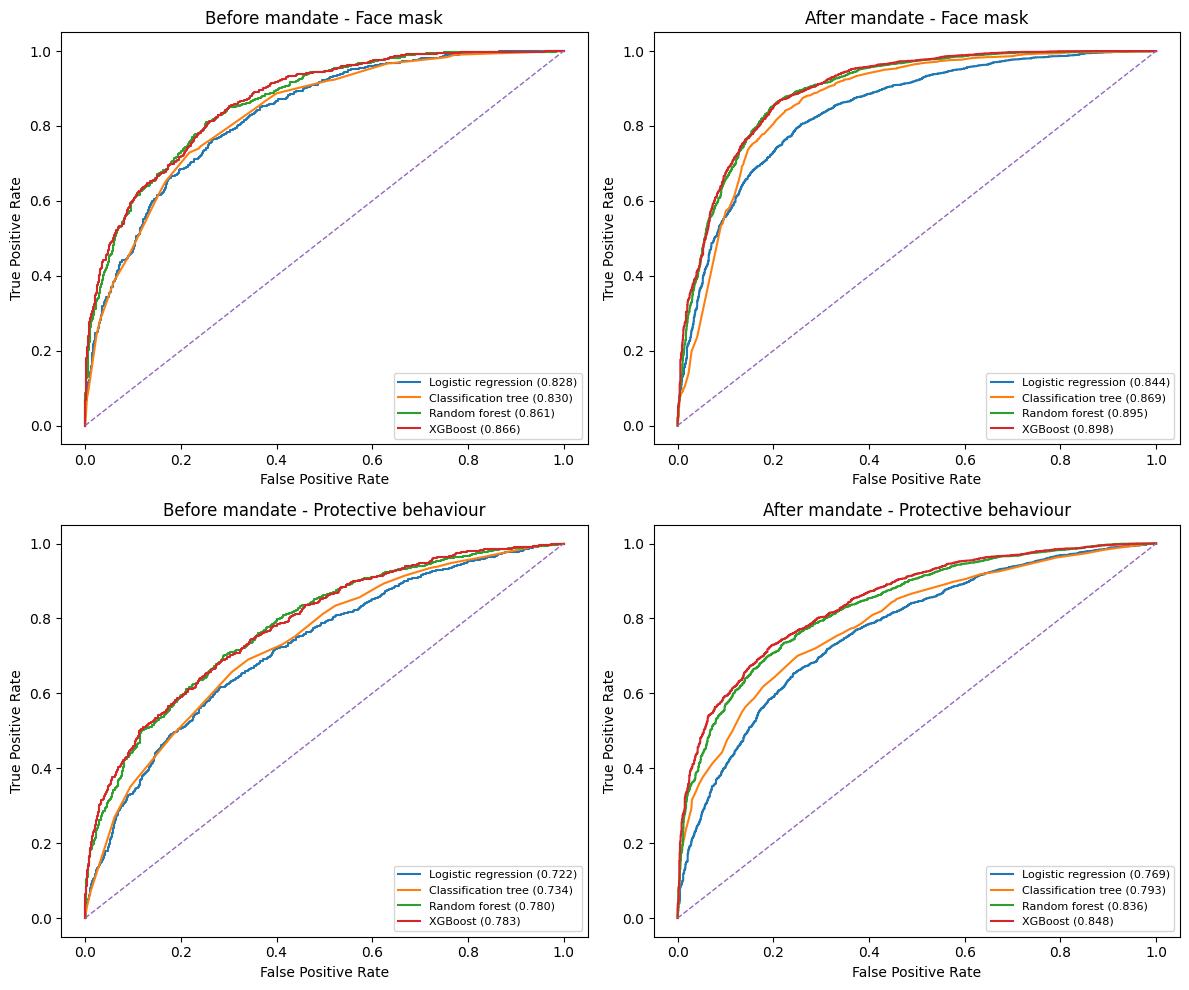

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))        # Create coordinates
axes = axes.flatten()

for ax, task in zip(axes, TASK_ORDER):                  # All models' ROC curves
    for model_name in MODEL_ORDER:
        res = all_results[task]["models"][model_name]
        y_true = res["y_test"]
        y_prob = res["y_test_prob"]

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, label=f"{MODEL_LABELS[model_name]} ({auc_val:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")

# Visulization
plt.tight_layout()
plt.savefig(RESULT_DIR / "roc_all_models_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

## 11. Feature importance

### 11.1 Prepare function

In [30]:
# XGBoost is the best model, so XGBOost is selected
def prepare_feature_importance(task_before, task_after, top_n=10, exclude_state=False):

    before_df = all_results[task_before]["models"]["xgboost"]["feature_df"].copy()
    after_df = all_results[task_after]["models"]["xgboost"]["feature_df"].copy()



    if exclude_state:                                                                                                   # Remove state related variables
        before_df = before_df[~before_df["feature"].str.contains("state", case=False, na=False)].copy()
        after_df = after_df[~after_df["feature"].str.contains("state", case=False, na=False)].copy()



    before_df["category"] = before_df["feature"].apply(feature_category)                                                # Assign categories
    after_df["category"] = after_df["feature"].apply(feature_category)




    before_df = before_df.rename(columns={"importance": "before_importance","category": "before_category"})             # Rename columns
    after_df = after_df.rename(columns={"importance": "after_importance","category": "after_category"})


    plot_df = pd.merge(before_df[["feature", "before_importance", "before_category"]],after_df[["feature", "after_importance", "after_category"]],on="feature",how="outer")       # Merge


    plot_df["before_importance"] = plot_df["before_importance"].fillna(0)                                               # Missing values is 0
    plot_df["after_importance"] = plot_df["after_importance"].fillna(0)


    plot_df["category"] = (plot_df["before_category"].fillna(plot_df["after_category"]).fillna("Other"))                # Keep category information
    plot_df["max_importance"] = plot_df[["before_importance", "after_importance"]].max(axis=1)                          # Sort
    plot_df = (plot_df.sort_values("max_importance", ascending=False).head(top_n).sort_values("max_importance", ascending=True).reset_index(drop=True))                            # The top 10 features

    return plot_df


In [31]:
# Plot before mandates and after mandatses feature importance
def plot_feature_importance(ax, plot_df, title, before_label="Before mandates", after_label="After mandates"):

    y = np.arange(len(plot_df))

    before_vals = -plot_df["before_importance"].values
    after_vals = plot_df["after_importance"].values

    colors = [CATEGORY_COLORS.get(c, "#999999") for c in plot_df["category"]]

    ax.barh(y, before_vals, color=colors)
    ax.barh(y, after_vals, color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["feature"])
    ax.set_xlabel("Feature importance")
    ax.set_title(title)
    ax.text(0.02, 1.02, before_label, transform=ax.transAxes,ha="left", va="bottom", fontsize=11)
    ax.text(0.98, 1.02, after_label, transform=ax.transAxes,ha="right", va="bottom", fontsize=11)

In [32]:
# Table functionn
def format_feature_importance_table(mask_df, prot_df, state_label):
    def format_table(df, outcome_name):
        table = df.copy()
        table["Outcome"] = outcome_name
        table["Before importance"] = table["before_importance"].round(4)
        table["After importance"] = table["after_importance"].round(4)
        table["Before importance (%)"] = (table["before_importance"] * 100).round(2)
        table["After importance (%)"] = (table["after_importance"] * 100).round(2)
        return table[["Outcome","feature","category","Before importance","After importance","Before importance (%)","After importance (%)"]].rename(columns={"feature": "Feature","category": "Category"})

    feature_table = pd.concat([format_table(mask_df, "Face mask wearing"),format_table(prot_df, "General protective behaviour")],ignore_index=True)

    display(Markdown(f"## Table TOP10 Feature importance {state_label}"))
    display(feature_table)

    return feature_table

### 11.2 Feature importance(Have State variables)

In [33]:
# Feature importance figure including state variables
def Feature_importance_include_State(top_n=10):

    mask_df = prepare_feature_importance("before_mask","after_mask",top_n=top_n,exclude_state=False)
    prot_df = prepare_feature_importance("before_protective","after_protective",top_n=top_n,exclude_state=False)

    fig, axes = plt.subplots(2, 1, figsize=(14, 14))

    plot_feature_importance(axes[0],mask_df,title="(a) Face mask wearing\nFeature importance (Include State): XGBoost")
    plot_feature_importance(axes[1],prot_df,title="(b) General protective behaviour\nFeature importance (Include State): XGBoost")

    handles = []
    labels = []

    for cat in CATEGORY_ORDER:
        if cat in mask_df["category"].values or cat in prot_df["category"].values:
            handles.append(plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[cat]))
            labels.append(cat)

    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(RESULT_DIR / "feature_importance_include_state.png", bbox_inches="tight", dpi=300)
    plt.show()

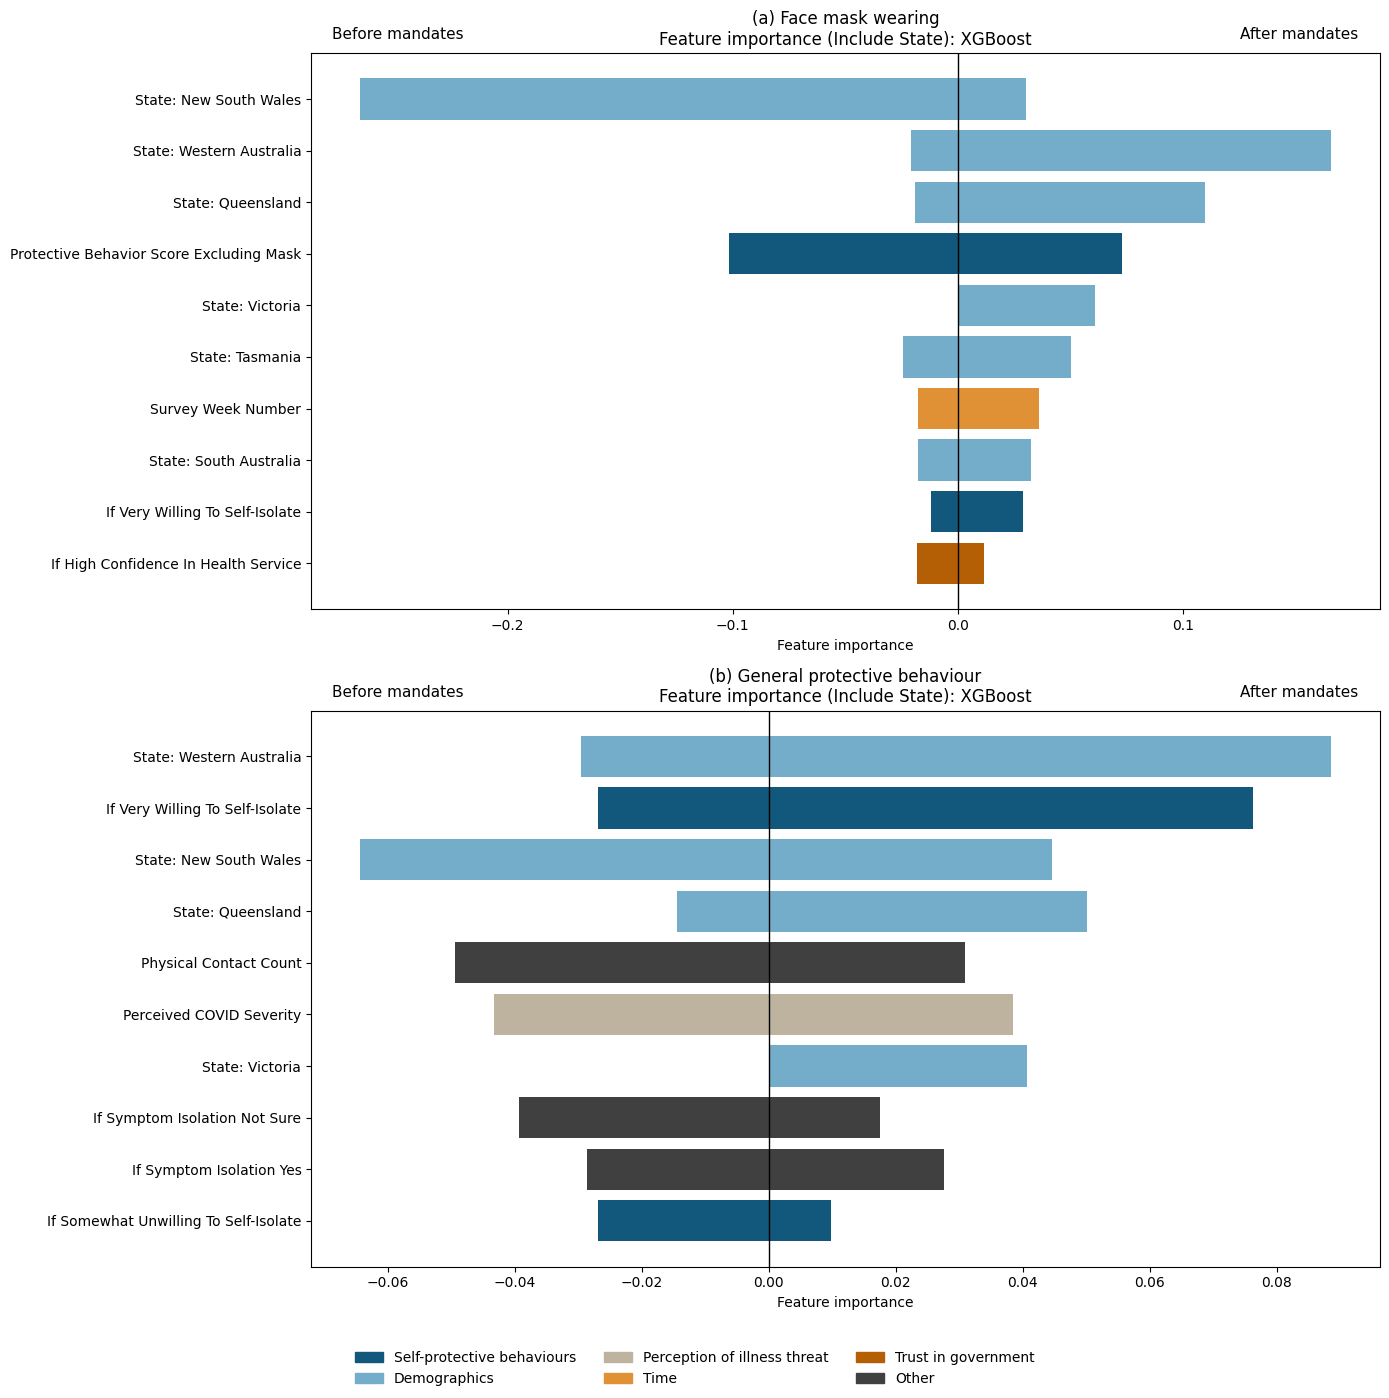

In [34]:
# Plot feature importance() have state variables)
Feature_importance_include_State(top_n=10)

In [35]:
# Feature importance table(have State)
def Feature_importance_include_State_table(top_n=10):
    mask_df = prepare_feature_importance("before_mask","after_mask",top_n=top_n,exclude_state=False)
    prot_df = prepare_feature_importance("before_protective","after_protective",top_n=top_n,exclude_state=False)
    table_include_state = format_feature_importance_table(mask_df,prot_df,state_label="(Have State)")
    table_include_state.to_csv(RESULT_DIR / "table_feature_importance_include_state.csv",index=False)

    return table_include_state

In [36]:
# Table feature importance(Have State)
table_feature_importance_include_state = Feature_importance_include_State_table(top_n=10)

## Table TOP10 Feature importance (Have State)

,Outcome,Feature,Category,Before importance,After importance,Before importance (%),After importance (%)
0,Face mask wearing,If High Confidence In Health Service,Trust in government,0.0183,0.0114,1.830000,1.14
1,Face mask wearing,If Very Willing To Self-Isolate,Self-protective behaviours,0.0121,0.0290,1.210000,2.90
2,Face mask wearing,State: South Australia,Demographics,0.0177,0.0323,1.770000,3.23
3,Face mask wearing,Survey Week Number,Time,0.0177,0.0358,1.770000,3.58
4,Face mask wearing,State: Tasmania,Demographics,0.0246,0.0502,2.460000,5.02
5,Face mask wearing,State: Victoria,Demographics,0.0000,0.0610,0.000000,6.10
6,Face mask wearing,Protective Behavior Score Excluding Mask,Self-protective behaviours,0.1016,0.0728,10.160000,7.28
7,Face mask wearing,State: Queensland,Demographics,0.0193,0.1095,1.930000,10.95
8,Face mask wearing,State: Western Australia,Demographics,0.0208,0.1658,2.080000,16.58
9,Face mask wearing,State: New South Wales,Demographics,0.2656,0.0300,26.559999,3.00


### 11.3 Feature importance(No State variables)

In [37]:
# Feature importance figure no state variables
def Feature_importance_no_State(top_n=10):

    mask_df = prepare_feature_importance("before_mask","after_mask",top_n=top_n,exclude_state=True)
    prot_df = prepare_feature_importance("before_protective","after_protective",top_n=top_n,exclude_state=True)

    fig, axes = plt.subplots(2, 1, figsize=(14, 14))

    plot_feature_importance(axes[0],mask_df,title="(a) Face mask wearing\nFeature importance (No State): XGBoost")
    plot_feature_importance(axes[1],prot_df,title="(b) General protective behaviour\nFeature importance (No State): XGBoost")

    handles = []
    labels = []

    for cat in CATEGORY_ORDER:
        if cat in mask_df["category"].values or cat in prot_df["category"].values:
            handles.append(plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[cat]))
            labels.append(cat)

    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(RESULT_DIR / "feature_importance_no_state.png", bbox_inches="tight", dpi=300)
    plt.show()

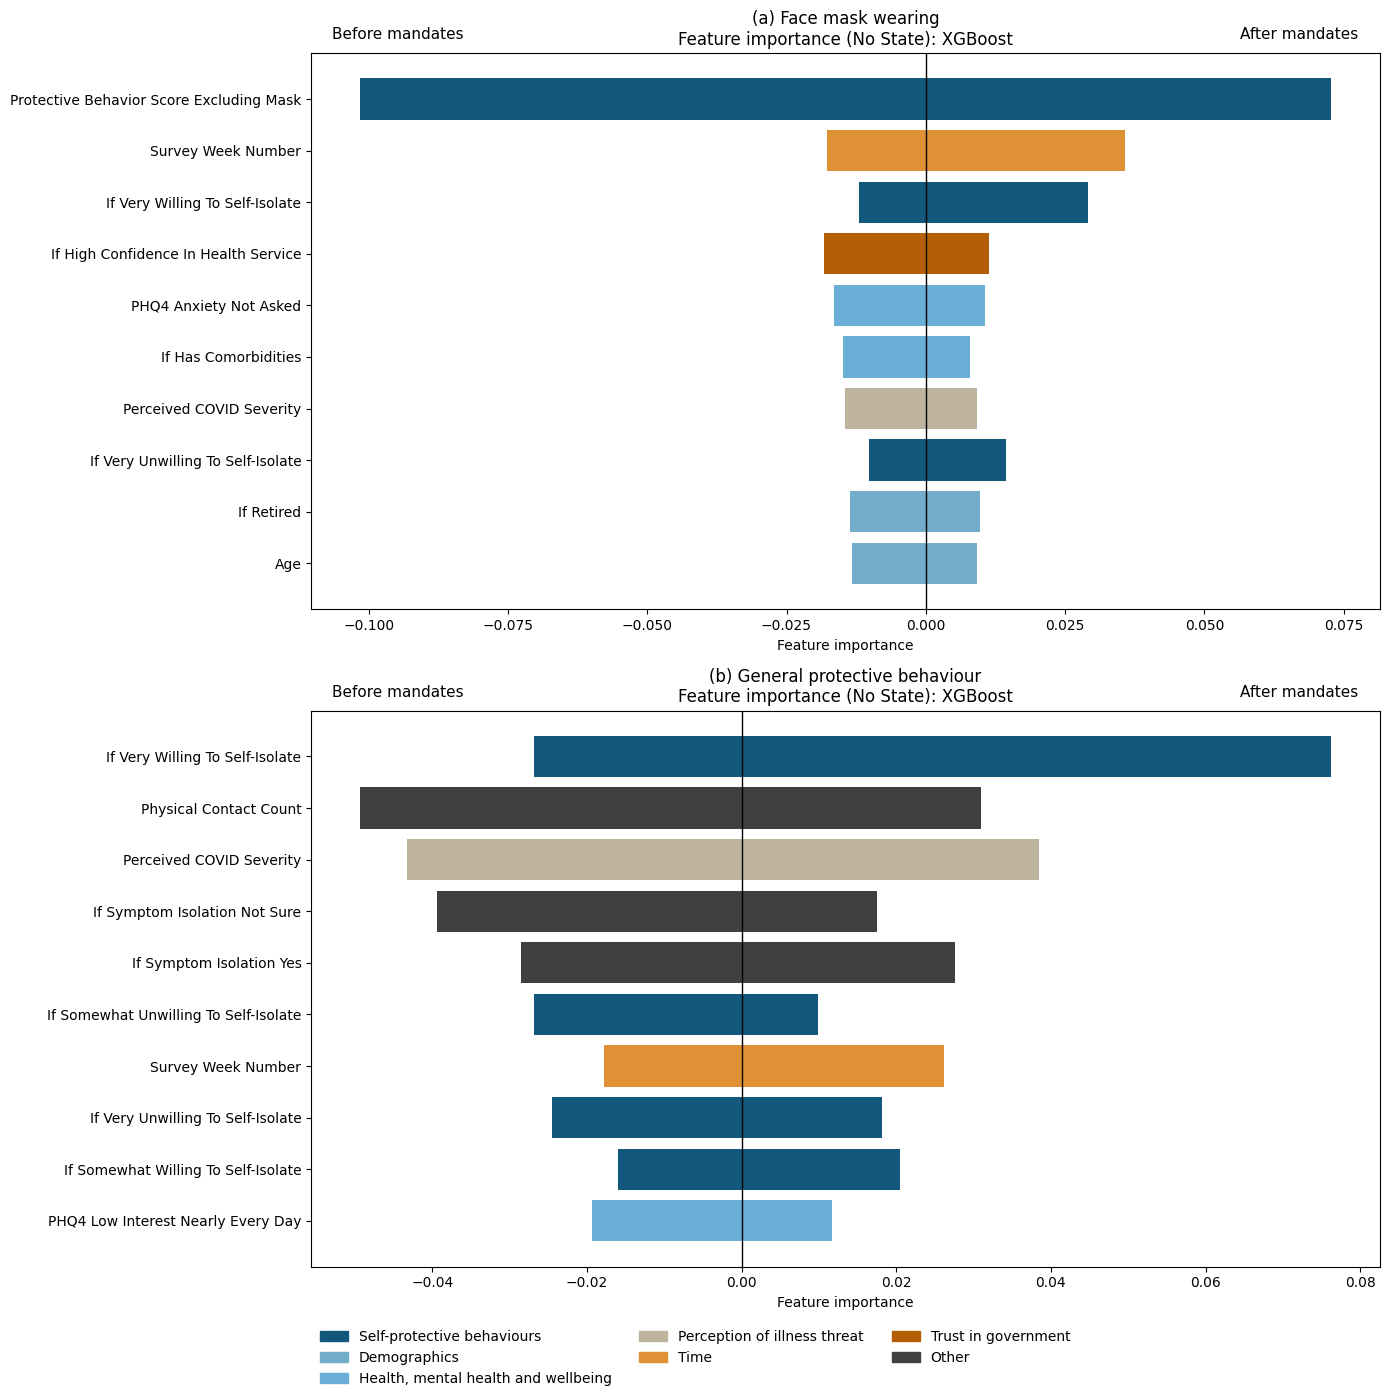

In [38]:
# Plot feature importance (no state variable)
Feature_importance_no_State(top_n=10)

In [39]:
# Feature importance table(No State)
def Feature_importance_no_State_table(top_n=10):
    mask_df = prepare_feature_importance("before_mask","after_mask",top_n=top_n,exclude_state=True)
    prot_df = prepare_feature_importance("before_protective","after_protective",top_n=top_n,exclude_state=True)
    table_no_state = format_feature_importance_table(mask_df,prot_df,state_label=" (No State)")
    table_no_state.to_csv(RESULT_DIR / "table_feature_importance_no_state.csv",index=False)
    return table_no_state

In [40]:
table_feature_importance_no_state = Feature_importance_no_State_table(top_n=10)

## Table TOP10 Feature importance  (No State)

,Outcome,Feature,Category,Before importance,After importance,Before importance (%),After importance (%)
0,Face mask wearing,Age,Demographics,0.0133,0.0092,1.33,0.92
1,Face mask wearing,If Retired,Demographics,0.0136,0.0098,1.36,0.98
2,Face mask wearing,If Very Unwilling To Self-Isolate,Self-protective behaviours,0.0103,0.0144,1.03,1.44
3,Face mask wearing,Perceived COVID Severity,Perception of illness threat,0.0145,0.0093,1.45,0.93
4,Face mask wearing,If Has Comorbidities,"Health, mental health and wellbeing",0.0148,0.0080,1.48,0.80
5,Face mask wearing,PHQ4 Anxiety Not Asked,"Health, mental health and wellbeing",0.0165,0.0105,1.65,1.05
6,Face mask wearing,If High Confidence In Health Service,Trust in government,0.0183,0.0114,1.83,1.14
7,Face mask wearing,If Very Willing To Self-Isolate,Self-protective behaviours,0.0121,0.0290,1.21,2.90
8,Face mask wearing,Survey Week Number,Time,0.0177,0.0358,1.77,3.58
9,Face mask wearing,Protective Behavior Score Excluding Mask,Self-protective behaviours,0.1016,0.0728,10.16,7.28
